## Predicting Student Academic Performance Using Behavioral and Academic Factors
### CMPS 6790 Final Project - Kyle Parfait - [kparfait17.github.io](https://kparfait17.github.io)

Academic performance is influenced by a combination of traditional academic indicators, behavioral habits, and environmental factors. Understanding which factors most strongly relate to student success can help educators identify intervention opportunities, improve student support systems, and better understand the drivers of achievement.

This project explores how both academic-history variables and lifestyle-related variables relate to student GPA, using two complementary student datasets. Through exploratory analysis and predictive modeling, this project investigates whether behavioral patterns such as study habits, attendance, and stress can meaningfully predict GPA, and whether academic-history variables provide stronger predictive power.

This problem is also relevant in data science because it represents a classic predictive modeling problem: identifying useful predictors, evaluating competing models, and determining which model structure best explains an outcome of interest.

### Research Questions
This analysis investigates three central questions:

1. Which student characteristics appear most associated with GPA?
2. Do academic-history variables outperform behavioral variables in predicting GPA?
3. What does comparing multiple regression models reveal about student performance prediction?

### Hypotheses
Before modeling, I expect:
- Previous GPA will be one of the strongest predictors of academic performance.
- Higher attendance and study time will positively relate to GPA.
- Behavioral predictors alone may have predictive value, but may underperform academic history variables.

### Background and Related Context

Prior educational research has consistently shown that attendance, prior achievement, and study habits influence academic outcomes. This project draws on those ideas while comparing whether traditional academic indicators or lifestyle variables offer better explanations.

### Resources informing this analysis:
- Predicting Student Performance Based on Online Study Habits (Sheshadri et al., 2019) - https://arxiv.org/abs/1904.07331
- Scikit-learn Linear Regression documentation - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- Statsmodels Regression Diagnostics - https://www.statsmodels.org/dev/examples/notebooks/generated/linear_regression_diagnostics_plots.html

These resources help motivated both the analysis and modeling choices used throughout the project.

### Data Collection and Description

This project uses two student datasets designed to capture different dimensions of academic performance.
The response variable of interest in both analyses is student GPA.

Dataset 1 contains behavioral and lifestyle-related variables such as:
- Daily study hours
- Attendance rate
- Stress level
- Social media usage
- Credits completed

Dataset 2 includes more traditional academic-history predictors such as:
- Previous GPA
- Study habits
- Attendance indicators

Using two datasets allows us to compare whether academic-history factors or lifestyle variables provide stronger predictive power.
Data Sources:
- https://www.kaggle.com/datasets/charlottebennett1234/lifestyle-factors-and-their-impact-on-students
- https://data.mendeley.com/datasets/dc3797vf3t/1/files/57b43a3a-a060-4247-afd9-cc17dfbf87f7

In [18]:
# Necessary imports for data manipulation, visualization, and modeling.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# Dataset 1 - Student Lifestyle Dataset
lifestyle_df = pd.read_csv("../data/student_lifestyle_dataset.csv")

# Dataset 2 - Student Academic Performance
student_df = pd.read_csv("../data/student_performance_dataset.csv")


#### Data Cleaning and Preparation

Before analysis, several preprocessing steps were performed to improve data quality and ensure variables were suitable for statistical analysis. Attendance values were converted to numeric form so they could be used in correlation and regression modeling. A small number of columns not directly relevant to the research questions (such as identifiers and administrative fields) were removed to simplify the analysis and focus on predictors related to academic performance.

In [8]:
# Clean attendance_rate (convert to numeric)
student_df["attendance_rate"] = pd.to_numeric(
    student_df["attendance_rate"],
    errors="coerce"
)

# Dropping columns not useful for analysis
student_df = student_df.drop(columns=["university_admission_year", "age", "hs_grad_year"])
lifestyle_df = lifestyle_df.drop(columns=["Student_ID"])

#### Dataset Data Types, Descriptions, and Column Names

In [9]:
student_df.dtypes

gender                            object
program                           object
current_semester                   int64
scholarship                       object
university_transport              object
daily_study_hours                  int64
seated_study_hours                 int64
learning_mode_preference          object
smart_phone_usage                 object
personal_computer                 object
social_media_hours                 int64
english_skills                    object
attendance_rate                  float64
probation                         object
suspension                        object
tutoring                          object
skills                            object
skill_development_daily_hours      int64
interested_area                   object
relationship_status               object
extracurriculars                  object
living_situation                  object
health_issues                     object
previous_gpa                     float64
physical_disabil

In [ ]:
student_df.describe()

,current_semester,daily_study_hours,seated_study_hours,social_media_hours,attendance_rate,skill_development_daily_hours,previous_gpa,gpa,credits_completed,family_income
count,1194.000000,1194.000000,1194.000000,1194.000000,1193.000000,1194.000000,1194.000000,1194.000000,1194.000000,1.194000e+03
mean,6.539363,3.131491,1.940536,3.289782,88.251467,2.185092,2.683945,3.165603,71.842546,6.248812e+04
std,3.809884,1.649597,0.856305,2.289547,15.319105,1.296101,0.871592,0.750132,48.074338,7.617356e+04
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+03
25%,3.000000,2.000000,1.000000,2.000000,80.000000,1.000000,2.200000,2.900000,23.000000,3.000000e+04
50%,7.000000,3.000000,2.000000,3.000000,93.000000,2.000000,2.680000,3.210000,78.000000,5.000000e+04
75%,10.000000,4.000000,2.000000,4.000000,100.000000,3.000000,3.380000,3.670000,117.000000,7.400000e+04
max,24.000000,13.000000,7.000000,20.000000,100.000000,12.000000,4.000000,4.000000,145.000000,2.000000e+06


In [ ]:
lifestyle_df.dtypes

Study_Hours_Per_Day                float64
Extracurricular_Hours_Per_Day      float64
Sleep_Hours_Per_Day                float64
Social_Hours_Per_Day               float64
Physical_Activity_Hours_Per_Day    float64
GPA                                float64
Stress_Level                        object
dtype: object

In [ ]:
lifestyle_df.describe()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


Summary statistics suggest reasonable variation across key predictors. 
Study hours are centered around moderate daily values, GPA exhibits meaningful but not extreme spread
Behavioral variables such as social and physical activity show enough variability to support later analysis.
These distributions suggest the data contain sufficient variation for exploring relationships with academic performance.

#### Study Habits and Attendance Patterns

- This section explores whether behavioral factors such as study time and attendance show meaningful relationships with GPA and whether those relationships support inclusion in later predictive models.

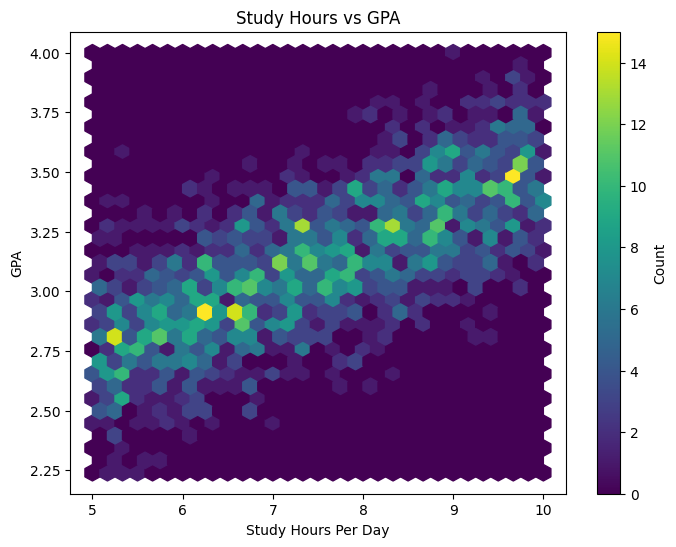

In [11]:
# Hexbin for daily study hours and GPA
plt.figure(figsize=(8, 6))

plt.hexbin(
    lifestyle_df["Study_Hours_Per_Day"],
    lifestyle_df["GPA"],
    gridsize=30
)

plt.colorbar(label="Count")
plt.xlabel("Study Hours Per Day")
plt.ylabel("GPA")
plt.title("Study Hours vs GPA")

plt.show()

The hexbin plot shows a clear positive relationship between study hours and GPA, with the densest concentration of observations following an upward trend. The diagonal band of high-density hexagons suggests that students who study more frequently tend to have higher GPAs, supporting the hypothesis that study behavior may be an important predictor in later regression models.

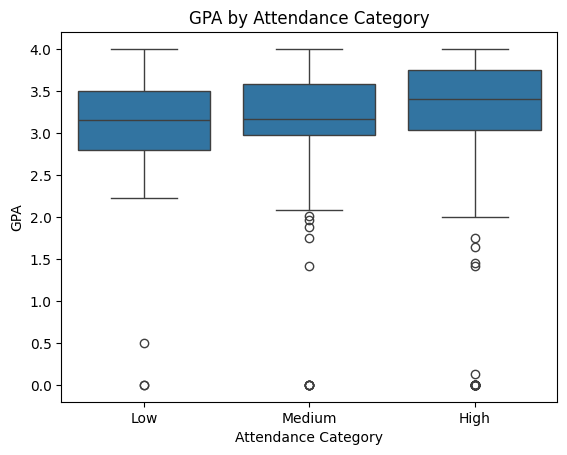

In [16]:
# Boxplot for attendance rate and GPA
student_df["attendance_category"] = pd.cut(
    student_df["attendance_rate"],
    bins=[0, 80, 90, 100],
    labels=["Low", "Medium", "High"]
)

sns.boxplot(data=student_df, x="attendance_category", y="gpa")
plt.title("GPA by Attendance Category")
plt.xlabel("Attendance Category")
plt.ylabel("GPA")
plt.show()

The boxplot suggests GPA tends to increase as attendance rises, with the high-attendance group showing a slightly higher median GPA than lower attendance groups. Although the distributions overlap, the upward shift in medians supports a positive relationship between attendance and academic performance.

Together, these early exploratory findings suggest study behavior and attendance may contribute meaningful predictive signal, motivating their inclusion in the regression models that follow.

#### Correlation Structure and Predictor Relationships

To further identify predictors most associated with GPA, correlation analysis is used to examine both pairwise relationships and broader predictor structure across the two datasets.

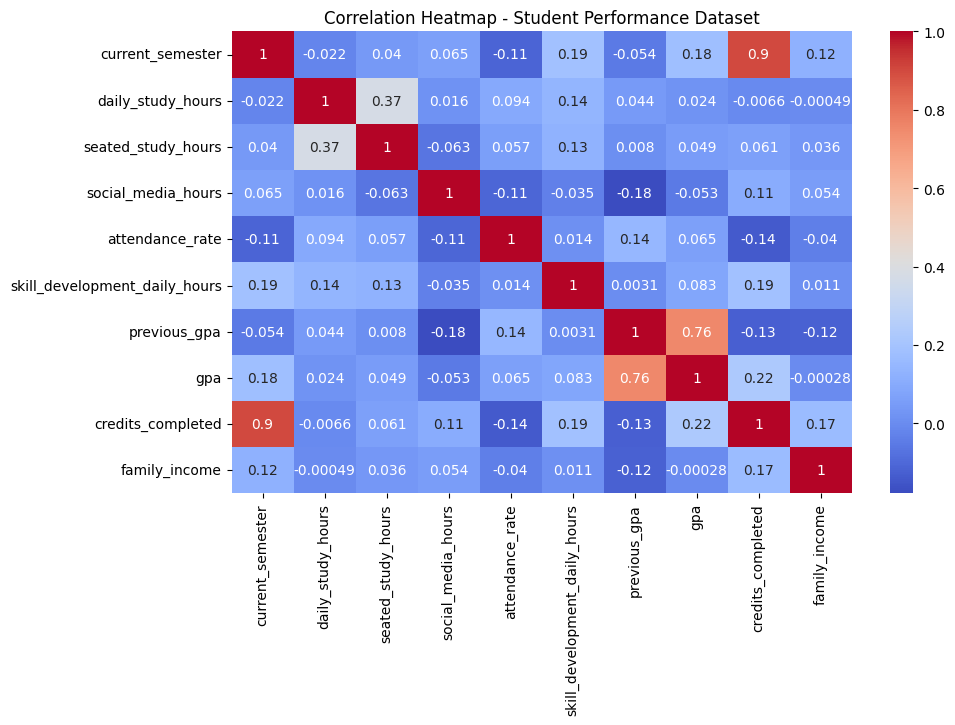

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(student_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Student Performance Dataset")
plt.show()

The heatmap suggests previous GPA is by far the strongest predictor of current GPA, with a substantial positive correlation (approximately 0.76). Credits completed and current semester show weaker but still positive relationships, while many behavioral variables appear comparatively less influential.

These results suggest academic-history variables may provide stronger predictive signal than daily behavioral measures, motivating comparison between the two regression models later in the analysis.

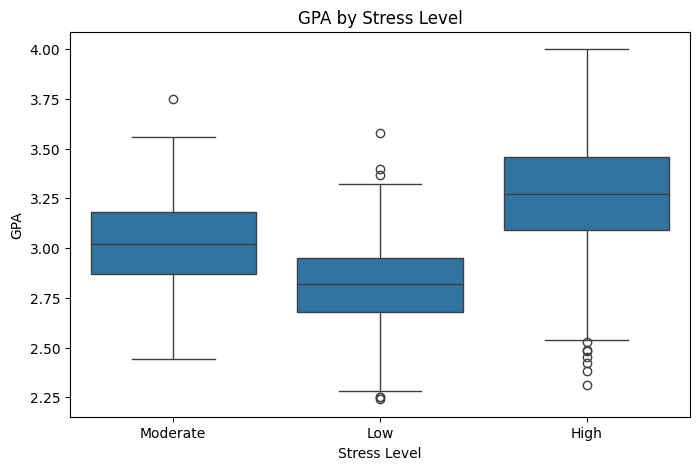

Stress_Level
High        3.261973
Low         2.816869
Moderate    3.024837
Name: GPA, dtype: float64

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=lifestyle_df, x="Stress_Level", y="GPA")
plt.title("GPA by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("GPA")
plt.show()

lifestyle_df["Sleep_Category"] = pd.cut(
    lifestyle_df["Sleep_Hours_Per_Day"],
    bins=[0, 5, 7, 10],
    labels=["Low", "Medium", "High"]
)

lifestyle_df.groupby("Stress_Level")["GPA"].mean()

Interestingly, students in the higher stress category show slightly higher average GPAs than lower stress groups. This suggests stress may not operate purely as a negative factor and may partially reflect academic pressure associated with high-performing students, highlighting a more nuanced relationship than initially expected.

While some relationships appear straightforward, others—such as stress—show that predictors may influence GPA in more complex ways than simple assumptions suggest.

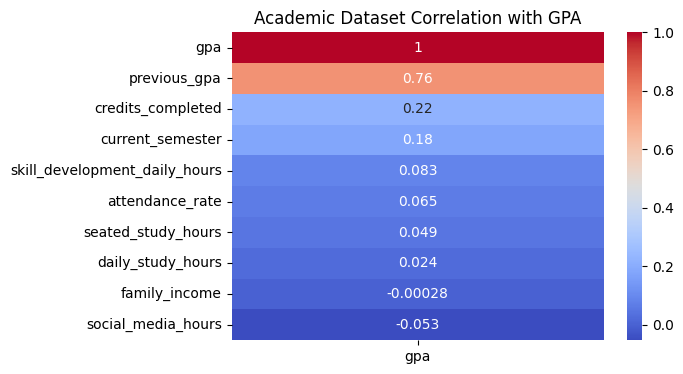

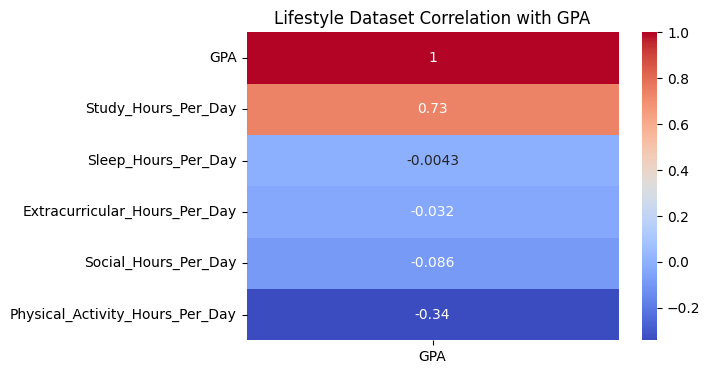

In [17]:
# These two heatmaps show the variables that have the strongest relationship with GPA.
correlation = student_df.corr(numeric_only=True)["gpa"].sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation.to_frame(), annot=True, cmap="coolwarm")
plt.title("Academic Dataset Correlation with GPA")
plt.show()

correlation = lifestyle_df.corr(numeric_only=True)["GPA"].sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation.to_frame(), annot=True, cmap="coolwarm")
plt.title("Lifestyle Dataset Correlation with GPA")
plt.show()

Comparing correlations across datasets reveals notable differences in predictor importance. In the academic-history dataset, previous GPA dominates as the strongest predictor, while in the lifestyle dataset study hours show the strongest relationship with GPA.

This comparison motivates evaluating whether academic-history predictors outperform behavioral predictors in formal regression models.

#### Model 1: Lifestyle Factors and GPA

Question:
- Can GPA be predicted using lifestyle factors such as study hours, sleep, and stress level?

Dependent Variable:
- GPA

Independent Variables:
- Study_Hours_Per_Day
- Sleep_Hours_Per_Day
- Stress_Level_Num

Methodology:
- A multiple linear regression model is used as an interpretable baseline for estimating how behavioral factors relate to GPA. A polynomial model is also tested to assess whether allowing nonlinear relationships meaningfully improves predictive performance.

Evalutation:
- To evaluate model performance, I examined explanatory power (R²), coefficient behavior, and whether allowing nonlinear structure improves predictive accuracy.

In [20]:
lifestyle_model_df = lifestyle_df.copy()

stress_map = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}

lifestyle_model_df["Stress_Level_Num"] = lifestyle_model_df["Stress_Level"].map(stress_map)

X = lifestyle_model_df[
    ["Study_Hours_Per_Day", "Sleep_Hours_Per_Day", "Stress_Level_Num"]
]
y = lifestyle_model_df["GPA"]

model1 = LinearRegression()
model1.fit(X, y)

# Adding polynomial regression model to capture potential nonlinear relationships
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(
    lifestyle_model_df[["Study_Hours_Per_Day", "Sleep_Hours_Per_Day", "Stress_Level_Num"]]
)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)

print("Intercept:", model1.intercept_)
print("Coefficients:", model1.coef_)
print("R^2:", model1.score(X, y))
print("R^2 (Polynomial):", model_poly.score(X_poly, y))

Intercept: 1.9998110518512138
Coefficients: [ 1.54143675e-01 -4.86835083e-03  1.35408994e-04]
R^2: 0.5400149395331738
R^2 (Polynomial): 0.5425051977972364


In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Fit model on training data
test_model1 = LinearRegression()
test_model1.fit(X_train, y_train)

# Predictions on unseen test data
y_pred = test_model1.predict(X_test)

# Evaluation metrics
r2_test = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test R²:", round(r2_test,3))
print("MAE:", round(mae,3))
print("RMSE:", round(rmse,3))

Test R²: 0.551
MAE: 0.164
RMSE: 0.205


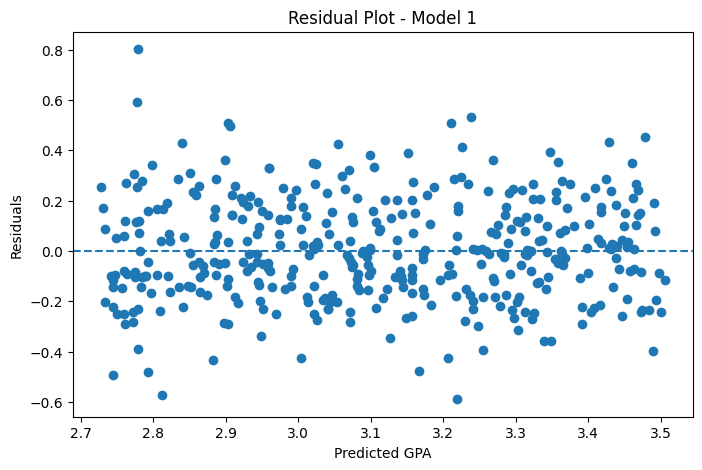

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted GPA")
plt.ylabel("Residuals")
plt.title("Residual Plot - Model 1")
plt.show()

The residuals appear fairly evenly scattered around zero, without any obvious pattern, which suggests the linear model is doing a reasonable job capturing the relationship in the data.

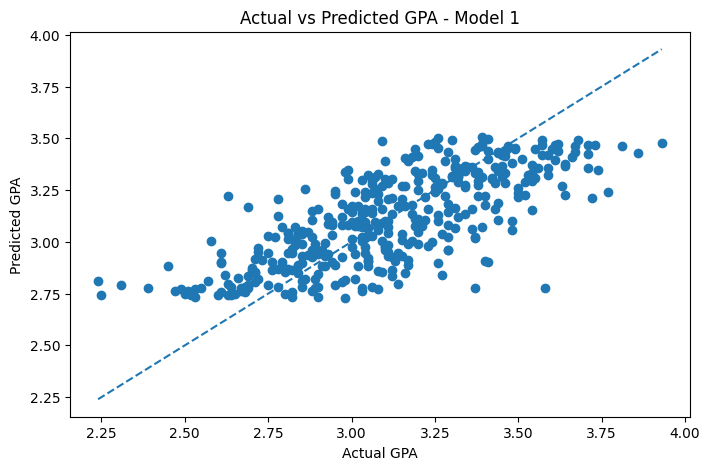

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA - Model 1")
plt.show()

#### Test-Set Performance

- To assess generalization, I evaluated the model was on held-out test data instead of just the training data.

- Test R² measures explanatory power on unseen observations, while MAE and RMSE quantify average prediction error.

- Residual diagnostics suggest whether model assumptions appear reasonable, while the actual-versus-predicted plot provides a visual assessment of prediction quality.

- Together, these diagnostics provide stronger evidence about model performance than training R² alone.

#### Model 1 Interpretation

The lifestyle regression model shows that behavioral predictors contain meaningful information about academic performance, with study hours contributing the strongest positive signal, while sleep and stress appear to have relatively small effects.

The model explains a moderate share of GPA variation (R² ≈ 0.54 on training data), and importantly, test-set performance remains similar (Test R² ≈ 0.55), suggesting the model generalizes reasonably well and does not appear heavily overfit.

Prediction error metrics (MAE = 0.164, RMSE = 0.205) indicate relatively modest average prediction error, though unexplained variability remains, reinforcing that behavioral factors alone do not fully determine GPA.

Residuals appear randomly scattered around zero with no strong systematic pattern, supporting the adequacy of the linear model assumptions. The actual-versus-predicted plot also shows predictions generally tracking observed GPA values, though some compression toward the mean suggests the model underpredicts very high GPAs and overpredicts some lower GPAs.

Testing a polynomial model produced only negligible improvement over linear regression, suggesting added complexity does not meaningfully improve predictive performance.

Overall, these results support the hypothesis that behavioral factors are meaningful—but limited—predictors of academic performance, while also motivating comparison with an academic-history model that may capture stronger predictive signal.

#### Model 2: Institutional and Academic Behavior Factors

Question:
Can GPA be predicted using academic and institutional factors such as study time, attendance, and credits completed?

Dependent Variable:
- gpa

Independent Variables:
- daily_study_hours
- attendance_rate
- social_media_hours
- credits_completed

Methodology:
- A second linear regression model is used to test whether academic and institutional predictors provide meaningful explanatory power for GPA and to compare their performance against the behavioral model.

In [25]:
student_model_df = student_df.copy()

# There was one value in the attendance_rate column that wasn't a simple integer, it was "94-98".
# I'm making sure the column is converted to numeric values, then dropping the offending row.
student_model_df["attendance_rate"] = pd.to_numeric(
    student_model_df["attendance_rate"],
    errors="coerce"
)

student_model_df = student_model_df.dropna(
    subset=["attendance_rate", "daily_study_hours", "social_media_hours", "credits_completed", "gpa"]
)

X2 = student_model_df[["daily_study_hours", "attendance_rate", "social_media_hours", "credits_completed"]]
y2 = student_model_df["gpa"]

model2 = LinearRegression()
model2.fit(X2, y2)

print("Intercept:", model2.intercept_)
print("Coefficients:", model2.coef_)
print("R^2:", model2.score(X2, y2))

Intercept: 2.5601509810027654
Coefficients: [ 0.00819391  0.0043469  -0.02271053  0.00377095]
R^2: 0.06349237758186699


In [26]:
# Train-test split for Model 2
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

# Fit Model 2 on training data
test_model2 = LinearRegression()
test_model2.fit(X2_train, y2_train)

# Predict on test data
y2_pred = test_model2.predict(X2_test)

# Evaluation metrics
r2_test_2 = r2_score(y2_test, y2_pred)
mae_2 = mean_absolute_error(y2_test, y2_pred)
rmse_2 = np.sqrt(mean_squared_error(y2_test, y2_pred))

print("Model 2 Test R²:", round(r2_test_2, 3))
print("Model 2 MAE:", round(mae_2, 3))
print("Model 2 RMSE:", round(rmse_2, 3))

Model 2 Test R²: 0.002
Model 2 MAE: 0.472
Model 2 RMSE: 0.64


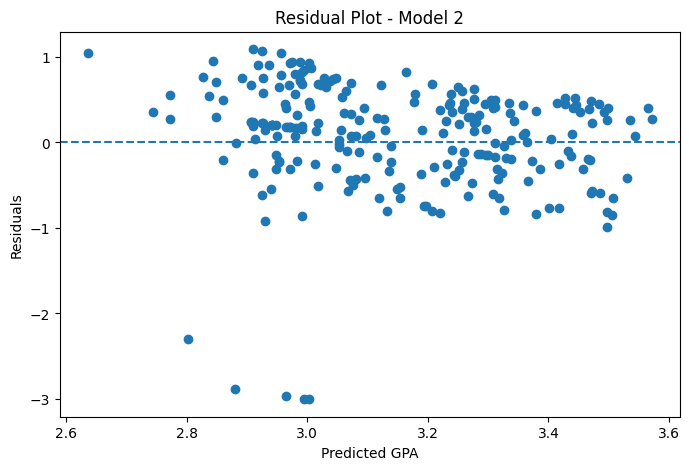

In [27]:
residuals_2 = y2_test - y2_pred

plt.figure(figsize=(8,5))
plt.scatter(y2_pred, residuals_2)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted GPA")
plt.ylabel("Residuals")
plt.title("Residual Plot - Model 2")
plt.show()

The residuals show a wider spread than Model 1, and several large errors appear below zero. This suggests Model 2 is missing important information and does not predict GPA as reliably as the lifestyle model.

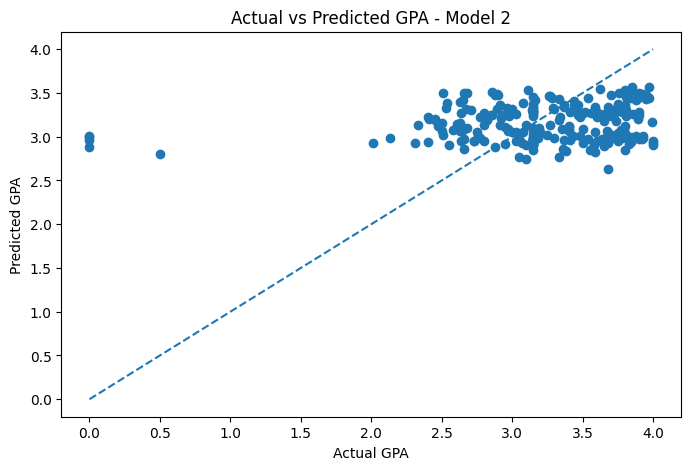

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(y2_test, y2_pred)
plt.plot(
    [y2_test.min(), y2_test.max()],
    [y2_test.min(), y2_test.max()],
    linestyle="--"
)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA - Model 2")
plt.show()

#### Model 2 Interpretation

Model 2 performs much weaker than Model 1. Although the training R² is already low at approximately 0.06, the test R² drops to nearly zero, meaning this model explains almost none of the variation in GPA on unseen data.

The MAE of 0.472 and RMSE of 0.64 are also much larger than Model 1’s errors, showing that this model’s predictions are less accurate. The residual plot confirms this pattern, with wider errors and several large misses.

Overall, this model suggests that daily study hours, attendance rate, social media hours, and credits completed do not provide enough predictive information by themselves. This likely occurs because the model excludes stronger academic-history variables, especially previous GPA, which the EDA showed had a much stronger relationship with current GPA.

#### Final Model Comparison

The two models produced substantially different predictive performance.

Model 1 (lifestyle factors) outperformed Model 2 across nearly every metric, with much higher explanatory power, lower prediction error, and stronger generalization on unseen data. This suggests behavioral factors in this dataset captured meaningful variation in GPA.

By contrast, Model 2 showed weak predictive performance, with near-zero test-set explanatory power and much larger prediction errors, suggesting the selected academic and institutional variables contributed limited predictive signal in this specification.

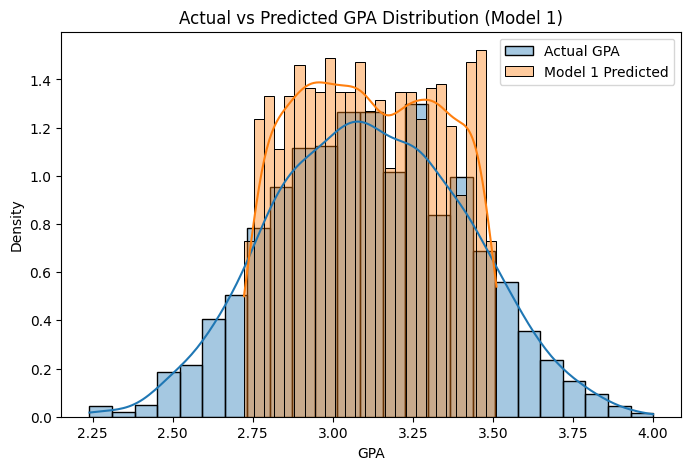

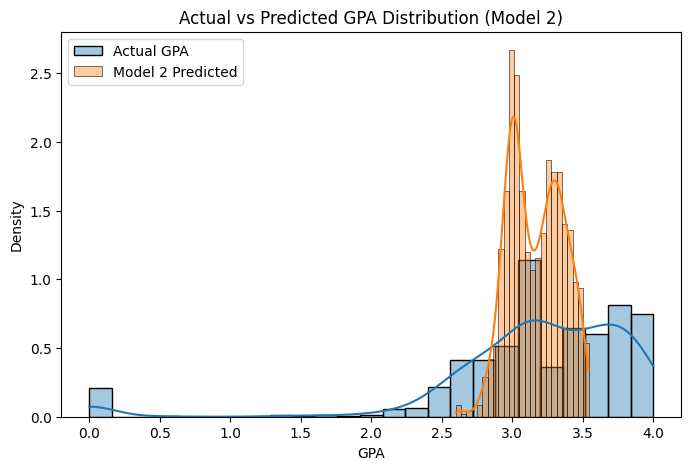

In [ ]:
# Plotting actual GPAs and predicted GPAs
lifestyle_model_df["GPA_Pred_Model1"] = model1.predict(X)
student_model_df["GPA_Pred_Model2"] = model2.predict(X2)

plt.figure(figsize=(8, 5))
# Actual GPA
sns.histplot(lifestyle_df["GPA"], bins=25, kde=True, label="Actual GPA", stat="density", alpha=0.4)
# Model 1 predictions
sns.histplot(lifestyle_model_df["GPA_Pred_Model1"], bins=25, kde=True, label="Model 1 Predicted", stat="density", alpha=0.4)

plt.title("Actual vs Predicted GPA Distribution (Model 1)")
plt.xlabel("GPA")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
# Actual GPA
sns.histplot(student_df["gpa"], bins=25, kde=True, label="Actual GPA", stat="density", alpha=0.4)
# Model 2 Prediction
sns.histplot(student_model_df["GPA_Pred_Model2"], bins=25, kde=True, label="Model 2 Predicted", stat="density", alpha=0.4)

plt.title("Actual vs Predicted GPA Distribution (Model 2)")
plt.xlabel("GPA")
plt.ylabel("Density")
plt.legend()
plt.show()

#### Comparative Model Diagnostics

The distribution plots reinforce the quantitative model results.

For Model 1, predicted GPA values closely follow the shape and center of the actual GPA distribution, suggesting the model captures much of the underlying structure in the data, even if extreme values are somewhat smoothed.

For Model 2, predictions are much more compressed around the mean and fail to reproduce the full spread of observed GPA values. This aligns with the weaker test performance and suggests the model underfits the data.

Taken together, the visual diagnostics, error metrics, and test-set evaluation all indicate that Model 1 provides the stronger predictive framework.

### Model Performance Summary

| Metric | Model 1 | Model 2 |
|-------|--------|--------|
| Training R² | 0.54 | 0.06 |
| Test R² | 0.55 | 0.00 |
| MAE | 0.164 | 0.472 |
| RMSE | 0.205 | 0.640 |

### Conclusions and Recommendations

This analysis suggests behavioral variables, especially study habits, provided stronger predictive signal for GPA than the academic/institutional predictor set tested here.

Future modeling could improve performance by combining both behavioral predictors and stronger academic-history variables such as previous GPA into a unified model.

More broadly, these results suggest student performance may be best understood through models that integrate both behavior and academic context rather than relying on either alone.